## 1.Importing Libraries






In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## 2.Importing the dataset

In [2]:
github_url = "https://raw.githubusercontent.com/nisaklsoglu/GamingBehaviour/refs/heads/main/gaming_behavior.csv"

dataset = pd.read_csv(github_url)
print("Data successfully loaded from GitHub.")

Data successfully loaded from GitHub.


## 3. Analyze the data

In [3]:
dataset.shape

(40034, 13)

In [4]:
dataset.info

<bound method DataFrame.info of        PlayerID  Age  Gender Location   GameGenre  PlayTimeHours  \
0          9000   43    Male    Other    Strategy      16.271119   
1          9001   29  Female      USA    Strategy       5.525961   
2          9002   22  Female      USA      Sports       8.223755   
3          9003   35    Male      USA      Action       5.265351   
4          9004   33    Male   Europe      Action      15.531945   
...         ...  ...     ...      ...         ...            ...   
40029     49029   32    Male      USA    Strategy      20.619662   
40030     49030   44  Female    Other  Simulation      13.539280   
40031     49031   15  Female      USA         RPG       0.240057   
40032     49032   34    Male      USA      Sports      14.017818   
40033     49033   19    Male      USA      Sports      10.083804   

       InGamePurchases GameDifficulty  SessionsPerWeek  \
0                    0         Medium                6   
1                    0         Medium                5   
2                    0           Easy               16   
3                    1           Easy                9   
4                    0         Medium                2   
...                ...            ...              ...   
40029                0           Easy                4   
40030                0           Hard               19   
40031                1           Easy               10   
40032                1         Medium                3   
40033                0           Easy               13   

       AvgSessionDurationMinutes  PlayerLevel  AchievementsUnlocked  \
0                            108           79                    25   
1                            144           11                    10   
2                            142           35                    41   
3                             85           57                    47   
4                            131           95                    37   
...                          ...          ...                   ...   
40029                         75           85                    14   
40030                        114           71                    27   
40031                        176           29                     1   
40032                        128           70                    10   
40033                         84           72                    39   

      EngagementLevel  
0              Medium  
1              Medium  
2                High  
3              Medium  
4              Medium  
...               ...  
40029          Medium  
40030            High  
40031            High  
40032          Medium  
40033          Medium  

[40034 rows x 13 columns]>

In [5]:
dataset.isnull().sum()

,0
PlayerID,0
Age,0
Gender,0
Location,0
GameGenre,0
PlayTimeHours,0
InGamePurchases,0
GameDifficulty,0
SessionsPerWeek,0
AvgSessionDurationMinutes,0


In [6]:
print(f"{dataset.duplicated().sum()}")

0


In [ ]:
dataset.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


##4. Exploratory Data Analysis (EDA)

Skewness

In [7]:

numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns


skewness = dataset[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

InGamePurchases              1.493398
PlayerLevel                  0.018754
SessionsPerWeek              0.015517
PlayerID                     0.000000
PlayTimeHours               -0.002225
Age                         -0.004466
AchievementsUnlocked        -0.005136
AvgSessionDurationMinutes   -0.005632
dtype: float64


### 4.1 Distribution of Numerical Features

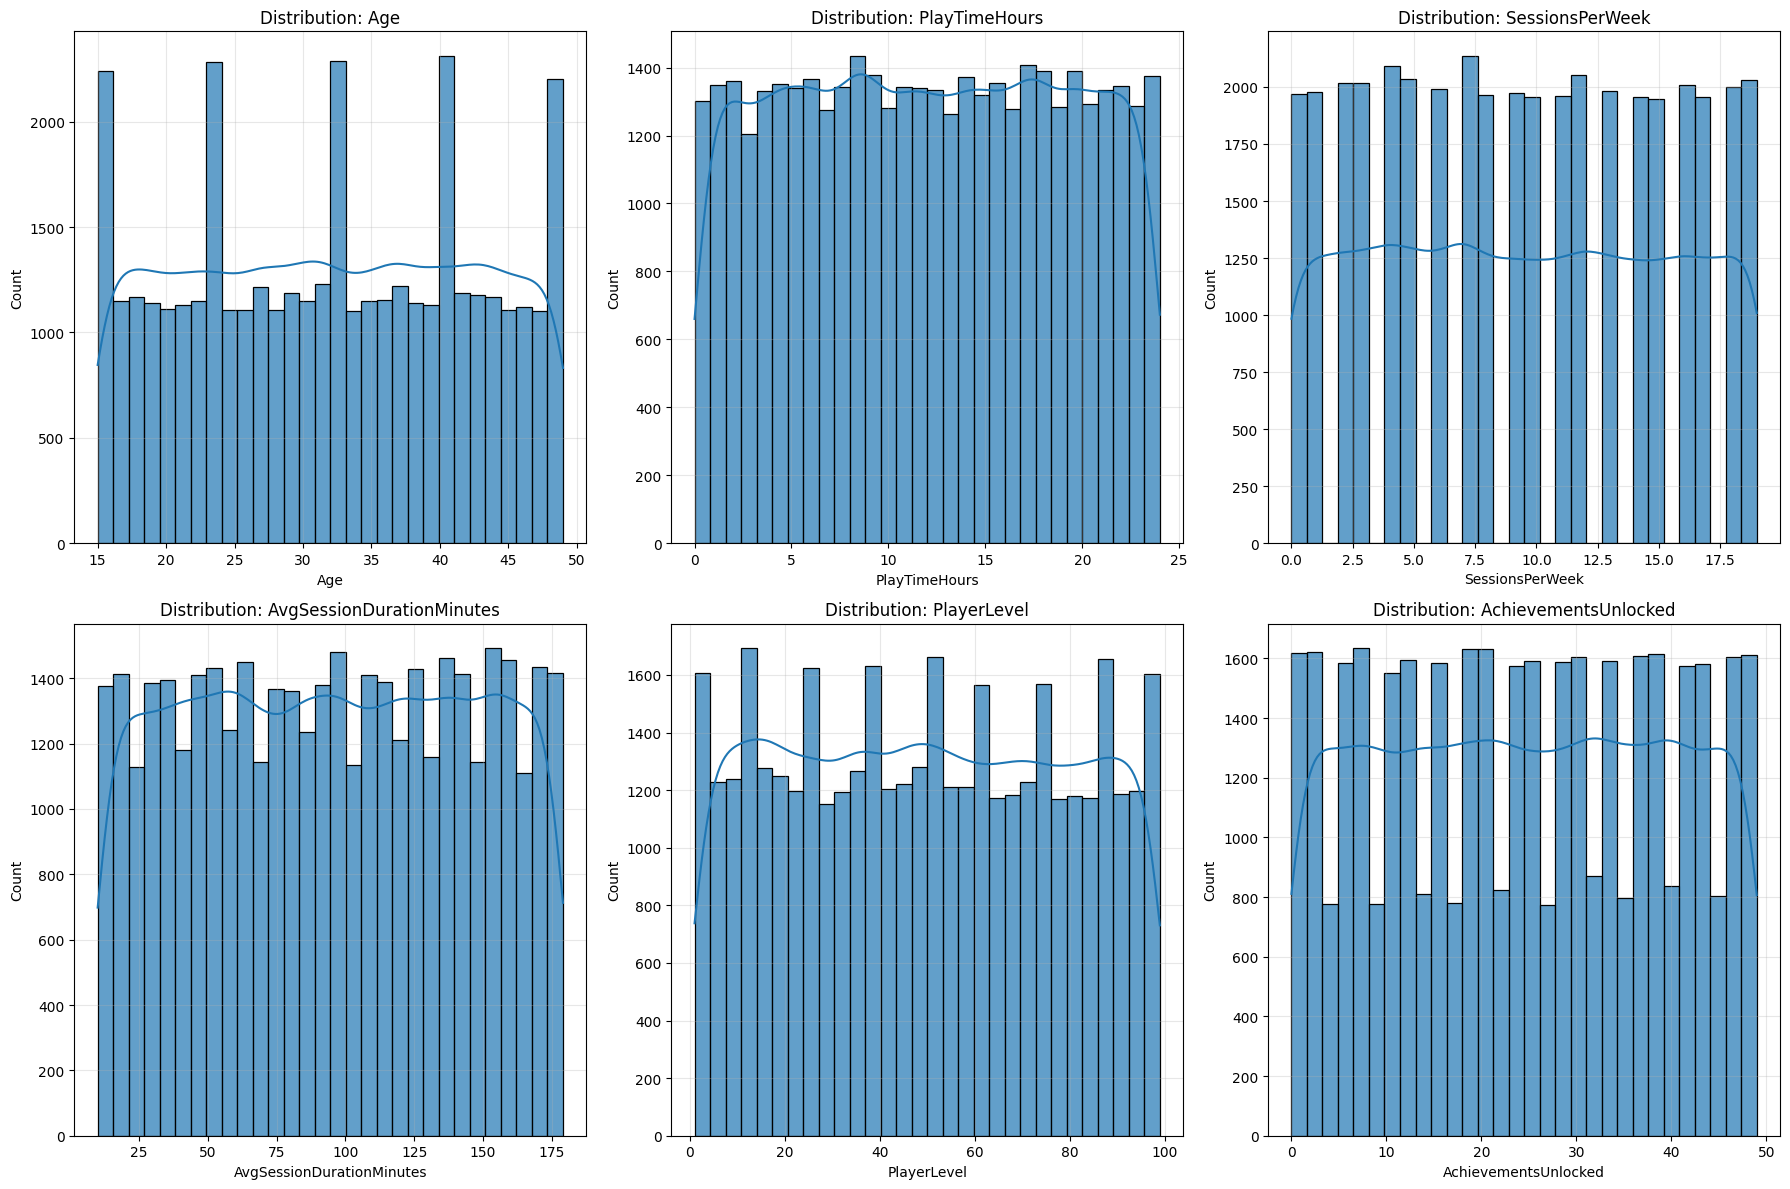

In [8]:


numerical_features = [
    'Age',
    'PlayTimeHours',
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'PlayerLevel',
    'AchievementsUnlocked'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes = axes.flatten()


for i, feature in enumerate(numerical_features):
    ax = axes[i]
    sns.histplot(
        dataset[feature],
        bins=30,
        kde=True,
        ax=ax,
        edgecolor='black',
        alpha=0.7
    )
    ax.set_title(f'Distribution: {feature}', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 Categorical Features Analysis

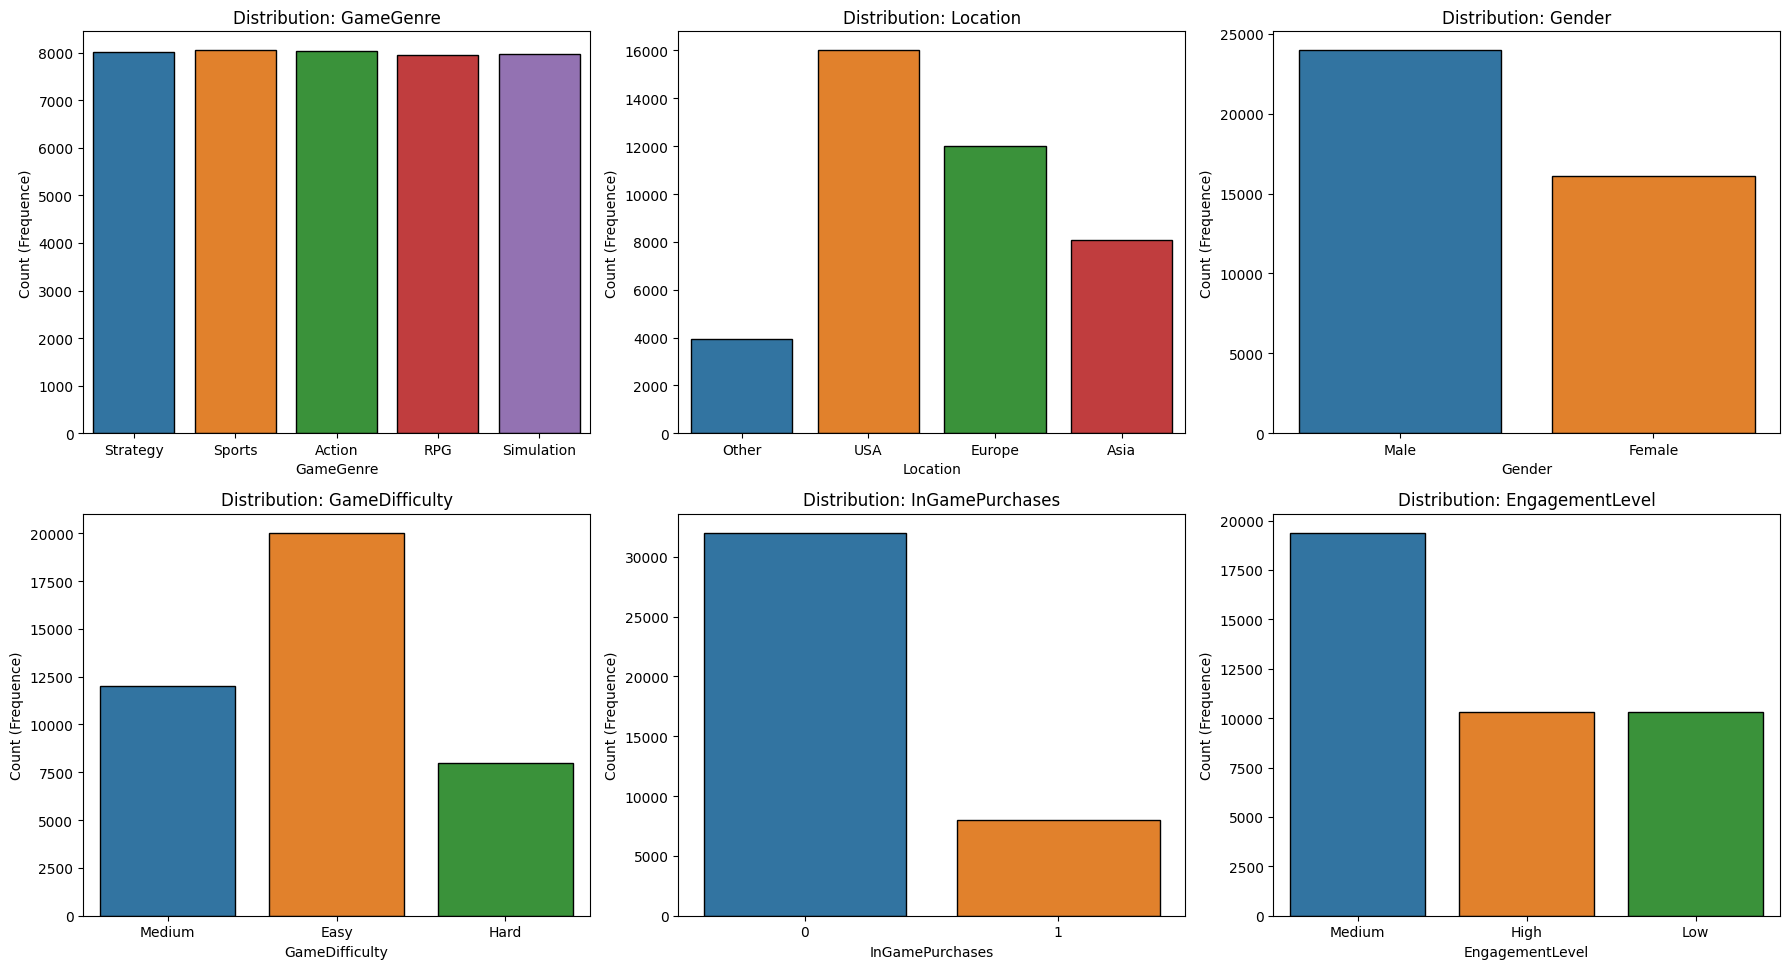

In [9]:


categorical_features = [
    'GameGenre',
    'Location',
    'Gender',
    'GameDifficulty',
    'InGamePurchases',
    'EngagementLevel'
]

num_features = len(categorical_features)
ncols = 3
nrows = int(np.ceil(num_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))


axes = axes.flatten()


for i, feature in enumerate(categorical_features):
    ax = axes[i]


    sns.countplot(
        x=feature,
        data=dataset,
        ax=ax,
        hue=feature,
        legend=False,

        edgecolor='black'
    )

    ax.set_title(f'Distribution: {feature}')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Count (Frequence)', fontsize=10)


total_plots = nrows * ncols
for i in range(num_features, total_plots):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 4.3 Correlation

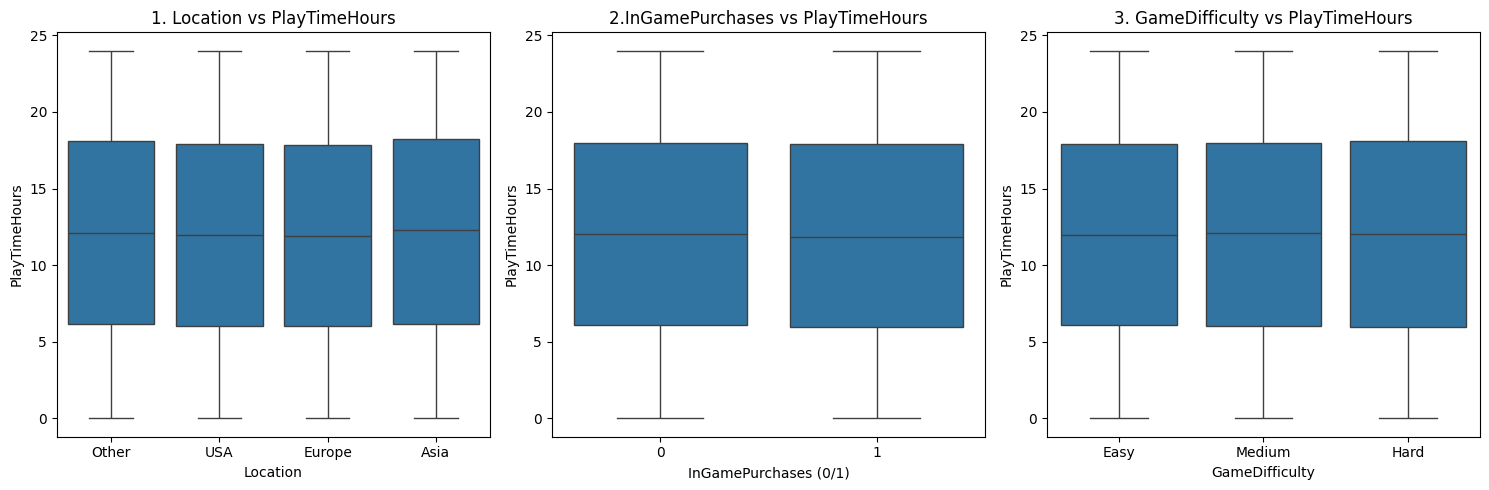

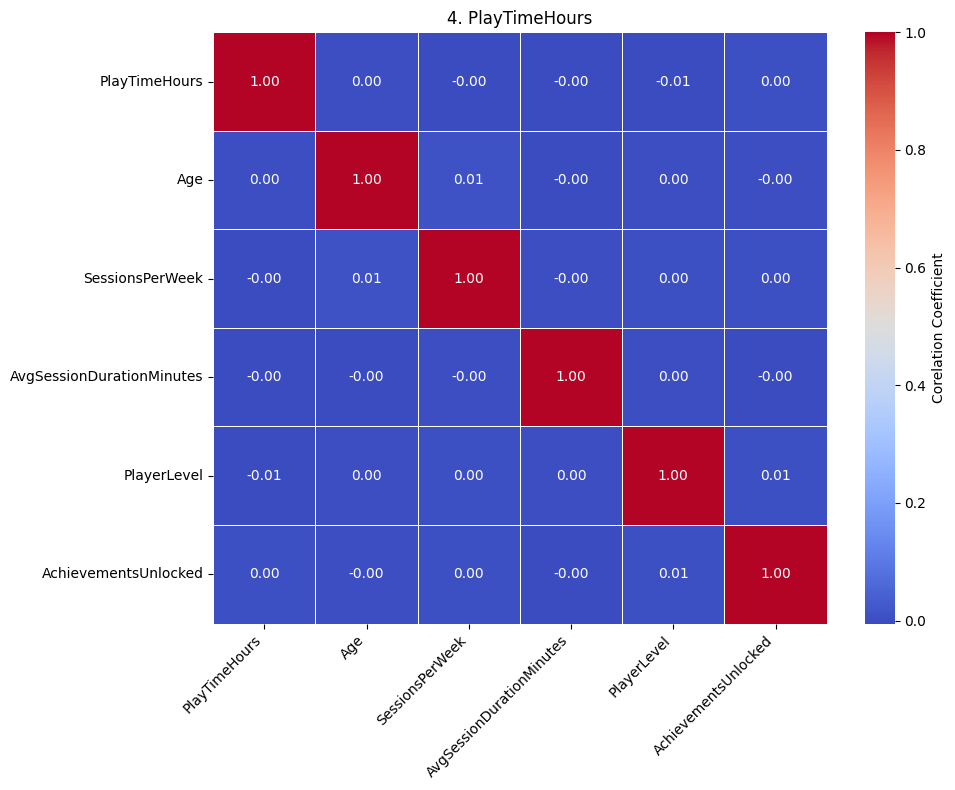

In [10]:



plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Location', y='PlayTimeHours', data=dataset)
plt.title('1. Location vs PlayTimeHours')
plt.xlabel('Location')
plt.ylabel('PlayTimeHours')


plt.subplot(1, 3, 2)
sns.boxplot(x='InGamePurchases', y='PlayTimeHours', data=dataset)
plt.title('2.InGamePurchases vs PlayTimeHours')
plt.xlabel('InGamePurchases (0/1)')
plt.ylabel('PlayTimeHours')

plt.subplot(1, 3, 3)
sns.boxplot(x='GameDifficulty', y='PlayTimeHours', data=dataset, order=['Easy', 'Medium', 'Hard'])
plt.title('3. GameDifficulty vs PlayTimeHours')
plt.xlabel('GameDifficulty')
plt.ylabel('PlayTimeHours')

plt.tight_layout()
plt.savefig("playtimehours_categorical_boxplots.png")
plt.show()

numerical_cols = [
    'PlayTimeHours',
    'Age',
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'PlayerLevel',
    'AchievementsUnlocked'
]
df_numeric = dataset[numerical_cols]
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Corelation Coefficient'}
)
plt.title('4. PlayTimeHours')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("playtimehours_numerical_correlation_heatmap.png")
plt.show()

The reason PlayTimeHours cannot be selected as the prediction target is its lack of a significant relationship with any of the features examined.

In [11]:


sns.set_style("whitegrid")
%matplotlib inline

np.set_printoptions(suppress=True, precision=4)

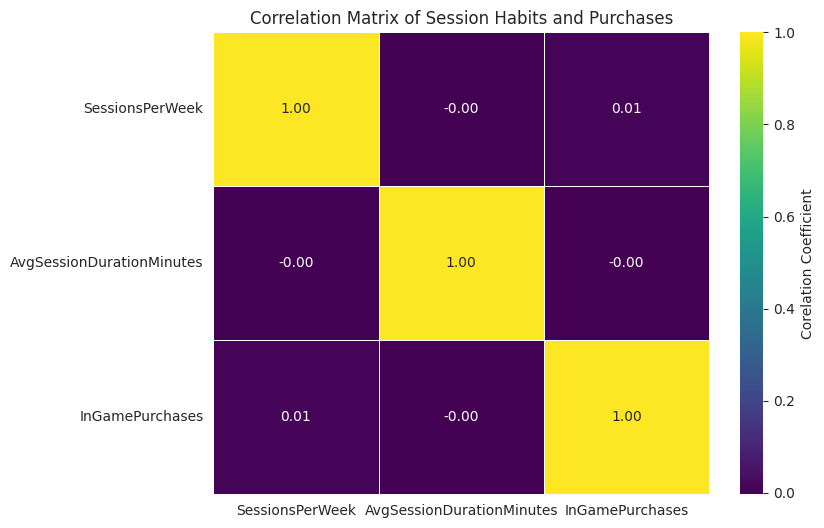

In [12]:


correlation_matrix = dataset[[
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'InGamePurchases'
]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Corelation Coefficient'}
)
plt.title('Correlation Matrix of Session Habits and Purchases')
plt.show()

There is no correlation between session habits and purchases.

Relationship Between Session Habits and Achievements

In [13]:
print("Relationship Between Session Habits and Achievements")
dataset['TotalWeeklyTimeMinutes'] = dataset['SessionsPerWeek'] * dataset['AvgSessionDurationMinutes']

correlation_new_features = dataset[[
    'AchievementsUnlocked',
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'TotalWeeklyTimeMinutes'
]].corr()

print("Session Feature with the Highest Correlation to Achievements")
print(correlation_new_features['AchievementsUnlocked'].sort_values(ascending=False))

Relationship Between Session Habits and Achievements
Session Feature with the Highest Correlation to Achievements
AchievementsUnlocked         1.000000
SessionsPerWeek              0.003187
TotalWeeklyTimeMinutes       0.001508
AvgSessionDurationMinutes   -0.002227
Name: AchievementsUnlocked, dtype: float64


Relationship Between Session Habits and Achievements

Average Metrics by Engagement Level

Avarege Metrics By Engagement Level
                 PlayTimeHours  SessionsPerWeek  AchievementsUnlocked
EngagementLevel                                                      
High                     12.07            14.25                 25.10
Low                      12.10             4.53                 22.66
Medium                   11.96             9.55                 25.22


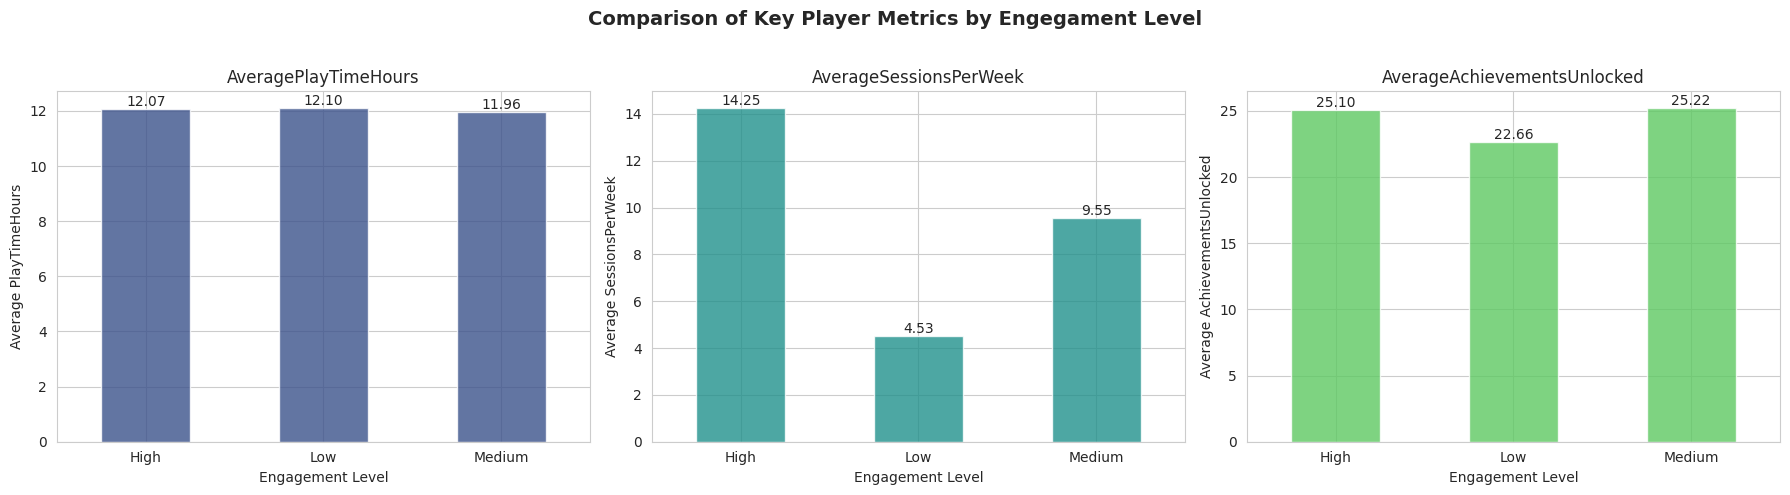

In [14]:
comparison_metrics = dataset.groupby('EngagementLevel')[[
    'PlayTimeHours',
    'SessionsPerWeek',
    'AchievementsUnlocked'
]].mean()

print("Avarege Metrics By Engagement Level")
print(comparison_metrics.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparison of Key Player Metrics by Engegament Level', fontsize=14, fontweight='bold')

metrics = ['PlayTimeHours', 'SessionsPerWeek', 'AchievementsUnlocked']
colors = sns.color_palette("viridis", 3)

for i, metric in enumerate(metrics):
    data = dataset.groupby('EngagementLevel')[metric].mean()
    data.plot(kind='bar', ax=axes[i], color=colors[i], alpha=0.8)

    axes[i].set_title(f'Average{metric}')
    axes[i].set_xlabel('Engagement Level')
    axes[i].set_ylabel(f'Average {metric}')
    axes[i].tick_params(axis='x', rotation=0)

    for idx, val in enumerate(data.values):
        axes[i].text(idx, val, f'{val:.2f}', ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The number of "SessionsPerWeek" is the most distinct factor in defining the different Engagement Levels.

Difficulty-Adjusted Achievement Score

In [15]:


difficulty_mapping = {
    'Easy': 1,
    'Medium': 2,
    'Hard': 4
}
dataset['Difficulty_Score'] = dataset['GameDifficulty'].map(difficulty_mapping)

print("GameDifficulty Transformation (First 5 Rows):")
print(dataset[['GameDifficulty', 'Difficulty_Score']].head())

GameDifficulty Transformation (First 5 Rows):
  GameDifficulty  Difficulty_Score
0         Medium                 2
1         Medium                 2
2           Easy                 1
3           Easy                 1
4         Medium                 2


In [17]:
dataset['DAAS'] = dataset['AchievementsUnlocked'] * dataset['Difficulty_Score']

print("\nNew Feature (DAAS) Statistics:")
print(dataset['DAAS'].describe())


New Feature (DAAS) Statistics:
count    40034.000000
mean        46.465504
std         42.026530
min          0.000000
25%         17.000000
50%         35.000000
75%         62.000000
max        196.000000
Name: DAAS, dtype: float64


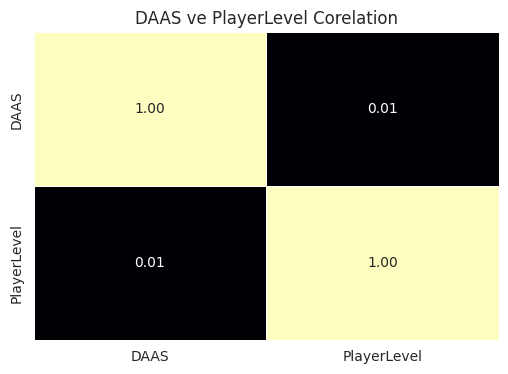

DAAS and PlayerLevel Corelation Coefficient (r): 0.0074


In [18]:


correlation_matrix_daas = dataset[['DAAS', 'PlayerLevel']].corr()


plt.figure(figsize=(6, 4))
sns.heatmap(
    correlation_matrix_daas,
    annot=True,
    cmap='magma',
    fmt=".2f",
    linewidths=.5,
    cbar=False
)
plt.title('DAAS ve PlayerLevel Corelation')
plt.show()

daas_playerlevel_corr = dataset['DAAS'].corr(dataset['PlayerLevel'])
print(f"DAAS and PlayerLevel Corelation Coefficient (r): {daas_playerlevel_corr:.4f}")

A new composite feature, named 'DAAS' (Difficulty-Adjusted Achievement Score), was created by multiplying the existing 'AchievementsUnlocked' and the newly mapped 'Difficulty Score' columns. The subsequent analysis calculated the statistics for this new feature and examined its correlation with 'PlayerLevel'.The correlation coefficient r is 0.0074 (which is rounded to 0.01 in the heatmap). This extremely low value suggests that there is no meaningful linear relationship between the Difficulty-Adjusted Achievement Score (DAAS) and the player's overall level.

Play Time and Purchase Relationship

<Figure size 800x800 with 0 Axes>

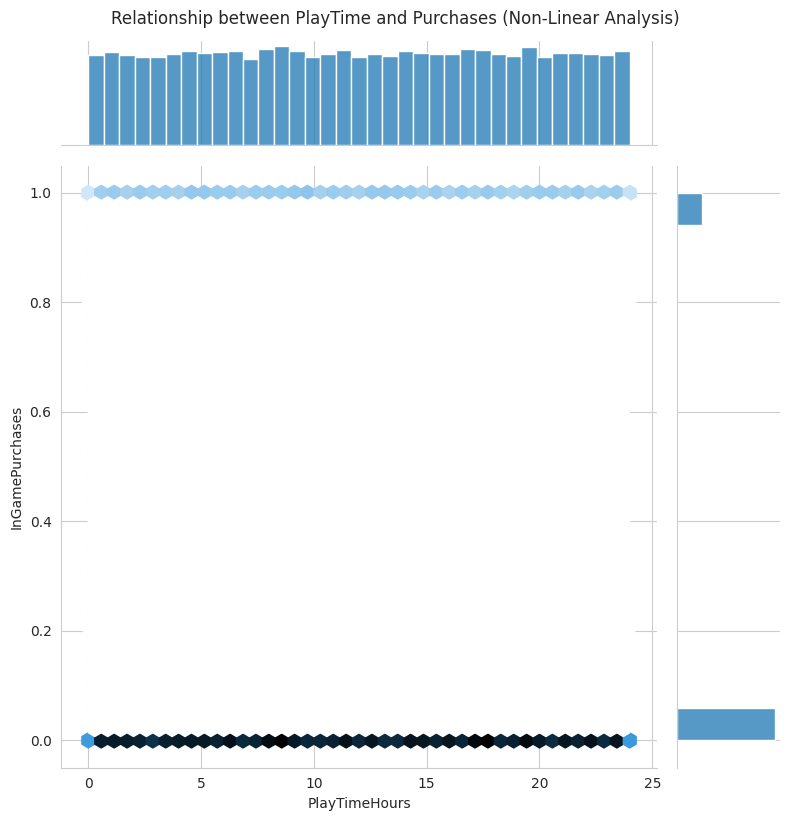

In [19]:
plt.figure(figsize=(8, 8))
sns.jointplot(x='PlayTimeHours', y='InGamePurchases', data=dataset, kind='hex', height=8)
plt.suptitle("Relationship between PlayTime and Purchases (Non-Linear Analysis)", y=1.02)
plt.show()

The tendency to purchase does not increase or decrease as play time increases

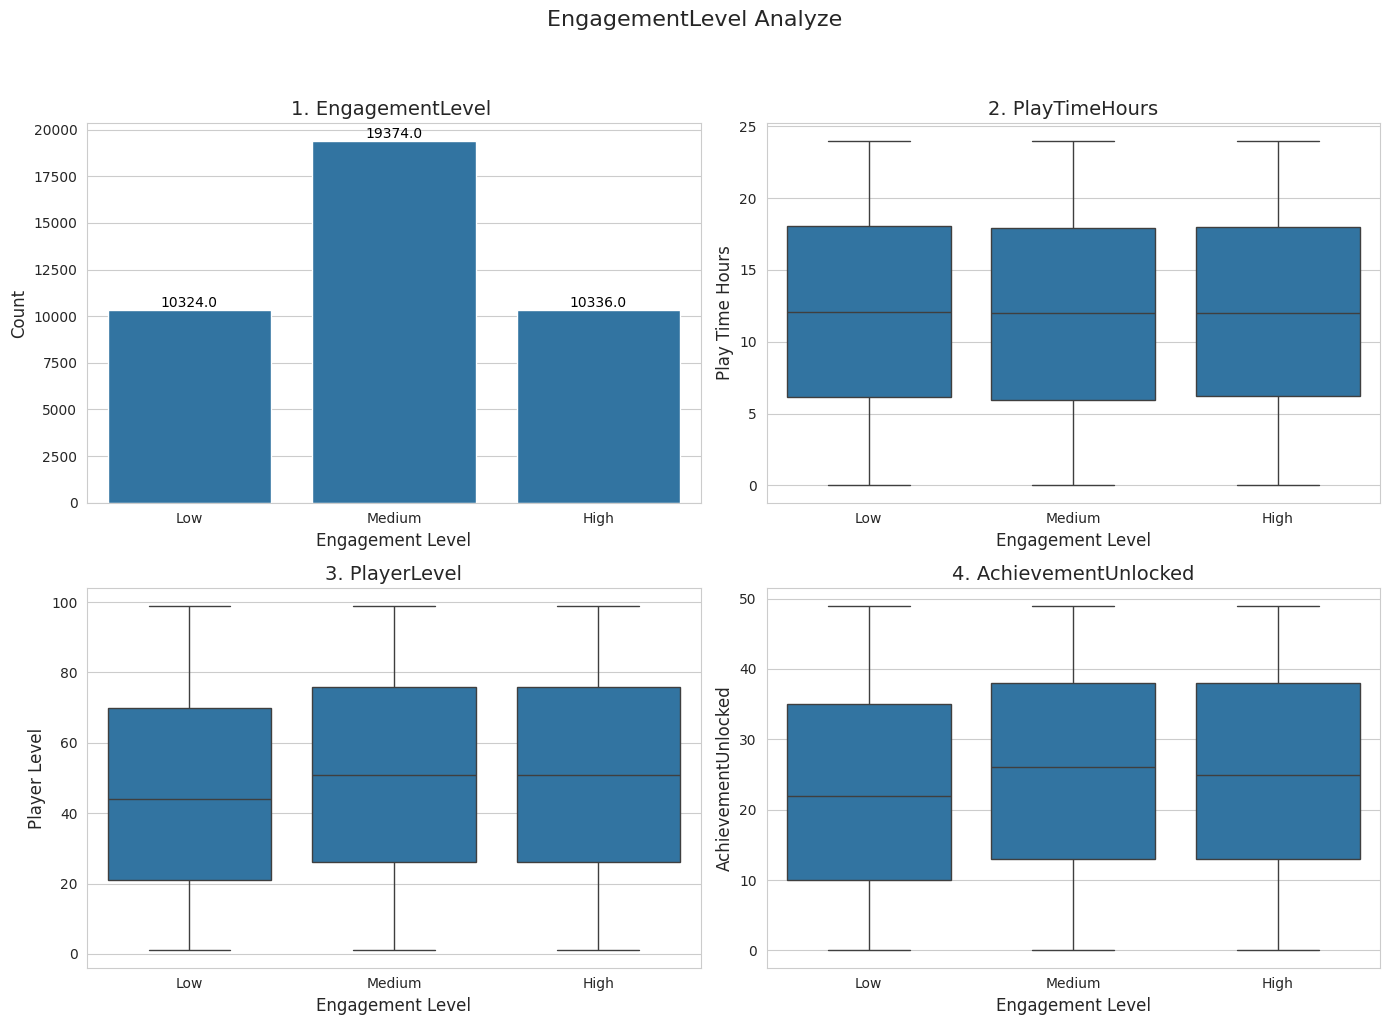

In [20]:

engagement_order = ['Low', 'Medium', 'High']

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EngagementLevel Analyze', fontsize=16, y=1.02)


sns.countplot(x='EngagementLevel', data=dataset, order=engagement_order, ax=axes[0, 0])
axes[0, 0].set_title('1. EngagementLevel ', fontsize=14)
axes[0, 0].set_xlabel('Engagement Level', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)

for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')


sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=dataset, order=engagement_order, ax=axes[0, 1])
axes[0, 1].set_title('2. PlayTimeHours', fontsize=14)
axes[0, 1].set_xlabel('Engagement Level', fontsize=12)
axes[0, 1].set_ylabel('Play Time Hours', fontsize=12)

sns.boxplot(x='EngagementLevel', y='PlayerLevel', data=dataset, order=engagement_order, ax=axes[1, 0])
axes[1, 0].set_title('3. PlayerLevel', fontsize=14)
axes[1, 0].set_xlabel('Engagement Level', fontsize=12)
axes[1, 0].set_ylabel('Player Level', fontsize=12)


sns.boxplot(x='EngagementLevel', y='AchievementsUnlocked', data=dataset, order=engagement_order, ax=axes[1, 1])
axes[1, 1].set_title('4. AchievementUnlocked', fontsize=14)
axes[1, 1].set_xlabel('Engagement Level', fontsize=12)
axes[1, 1].set_ylabel('AchievementUnlocked', fontsize=12)


plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


As shown in these charts, players with a 'High' engagement level have significantly higher average Play Time (Hours), Player Level, and Number of Achievements Unlocked compared to players at the 'Low' level

## Label Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Gender', 'GameDifficulty']

for col in categorical_cols:
    dataset[col] = le.fit_transform(dataset[col])


In [22]:

dataset.head(10)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalWeeklyTimeMinutes,Difficulty_Score,DAAS
0,9000,43,1,Other,Strategy,16.271119,0,2,6,108,79,25,Medium,648,2,50
1,9001,29,0,USA,Strategy,5.525961,0,2,5,144,11,10,Medium,720,2,20
2,9002,22,0,USA,Sports,8.223755,0,0,16,142,35,41,High,2272,1,41
3,9003,35,1,USA,Action,5.265351,1,0,9,85,57,47,Medium,765,1,47
4,9004,33,1,Europe,Action,15.531945,0,2,2,131,95,37,Medium,262,2,74
5,9005,37,1,Europe,RPG,20.561855,0,0,2,81,74,22,Low,162,1,22
6,9006,25,1,USA,Action,9.752716,0,1,1,50,13,2,Low,50,4,8
7,9007,25,0,Asia,RPG,4.401729,0,2,10,48,27,23,Medium,480,2,46
8,9008,38,0,Europe,Simulation,18.152733,0,0,5,101,23,41,Medium,505,1,41
9,9009,38,0,Other,Sports,23.942772,0,0,13,95,99,36,High,1235,1,36


In [23]:
# EngagementLevel mapping
dataset["EngagementLevel"] = dataset["EngagementLevel"].astype(str).str.strip().str.title()
dataset["EngagementLevel"] = dataset["EngagementLevel"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})


In [24]:
print("NaN:", dataset["EngagementLevel"].isna().sum())
dataset["EngagementLevel"].value_counts()


NaN: 0


,count
EngagementLevel,
1,19374
2,10336
0,10324


## One-Hot Encoding

In [25]:
dataset = pd.get_dummies(dataset, columns=['Location', 'GameGenre'], drop_first=True, dtype=int)
dataset.head(100)

,PlayerID,Age,Gender,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,...,TotalWeeklyTimeMinutes,Difficulty_Score,DAAS,Location_Europe,Location_Other,Location_USA,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy
0,9000,43,1,16.271119,0,2,6,108,79,25,...,648,2,50,0,1,0,0,0,0,1
1,9001,29,0,5.525961,0,2,5,144,11,10,...,720,2,20,0,0,1,0,0,0,1
2,9002,22,0,8.223755,0,0,16,142,35,41,...,2272,1,41,0,0,1,0,0,1,0
3,9003,35,1,5.265351,1,0,9,85,57,47,...,765,1,47,0,0,1,0,0,0,0
4,9004,33,1,15.531945,0,2,2,131,95,37,...,262,2,74,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,9095,49,1,7.838045,0,0,19,126,3,14,...,2394,1,14,1,0,0,0,0,1,0
96,9096,28,1,9.208411,1,2,1,84,61,39,...,84,2,78,0,0,1,0,0,0,1
97,9097,17,1,8.644038,0,0,3,117,1,11,...,351,1,11,1,0,0,0,0,0,1
98,9098,15,0,5.970601,0,0,11,55,54,37,...,605,1,37,1,0,0,0,1,0,0


## Splitting the Data Set

In [26]:
# SHARED SPLIT

from sklearn.model_selection import train_test_split

X_shared = dataset.drop(columns=["EngagementLevel", "PlayerID"])
y_shared = dataset["EngagementLevel"]

print("NaN in target:", y_shared.isna().sum())
print("X/y:", X_shared.shape, y_shared.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_shared, y_shared,
    test_size=0.2,
    random_state=42,
    stratify=y_shared #class imbalance olmaması için yaptık stratify bu önemli test ve train setinde veri dengeli dağılmış olmalı aynı class oranları
)

print("Train:", X_train.shape, "Test:", X_test.shape)


NaN in target: 0
X/y: (40034, 19) (40034,)
Train: (32027, 19) Test: (8007, 19)


## Model Training


Model 1: Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8704883227176221

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      2065
           1       0.85      0.92      0.89      3875
           2       0.93      0.84      0.88      2067

    accuracy                           0.87      8007
   macro avg       0.88      0.86      0.87      8007
weighted avg       0.87      0.87      0.87      8007



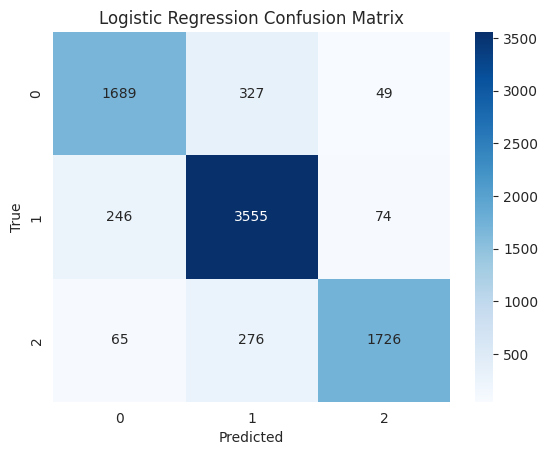

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 1) Model
log_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=5000,
    n_jobs=-1
)

# 2) Train
log_model.fit(X_train, y_train)

# 3) Predict
y_pred = log_model.predict(X_test)

# 4) Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Logistic Regression Confusion Matrix')
plt.show()


Model 2: Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [29]:
from sklearn.metrics import accuracy_score, f1_score

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("RF Macro-F1:", f1_score(y_test, rf_pred, average="macro"))


RF Accuracy: 0.9236917697015111
RF Macro-F1: 0.9194193711813111


<Figure size 600x500 with 0 Axes>

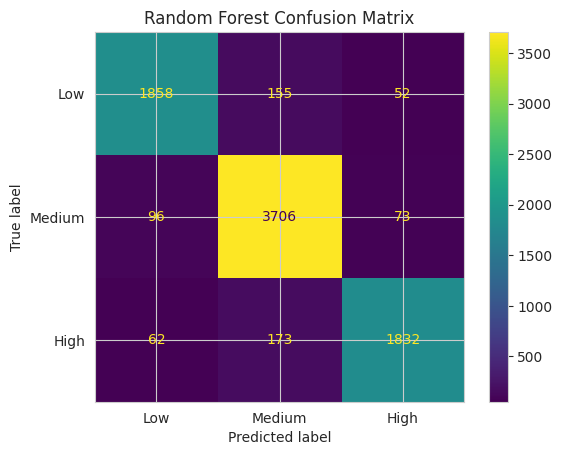

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_pred = rf_model.predict(X_test)

labels = [0, 1, 2]
label_names = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, rf_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

plt.figure(figsize=(6,5))
disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [31]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='f1_macro')

In [32]:
# En iyi RF modeli
best_rf = rf_search.best_estimator_

# Test set üzerinde tahmin
rf_pred_tuned = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score

print("Tuned RF Accuracy:", accuracy_score(y_test, rf_pred_tuned))
print("Tuned RF Macro-F1:", f1_score(y_test, rf_pred_tuned, average="macro"))



Tuned RF Accuracy: 0.9235668789808917
Tuned RF Macro-F1: 0.91930254258912


Permutation importance is being calculated (Random Forest)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Feature,Importance
9,TotalWeeklyTimeMinutes,5.571525e-01
7,PlayerLevel,3.113291e-02
8,AchievementsUnlocked,2.353344e-02
5,SessionsPerWeek,2.236893e-02
6,AvgSessionDurationMinutes,1.023702e-02
11,DAAS,8.249148e-03
1,Gender,4.057937e-04
12,Location_Europe,2.043537e-04
16,GameGenre_Simulation,1.306750e-04
15,GameGenre_RPG,1.064271e-04


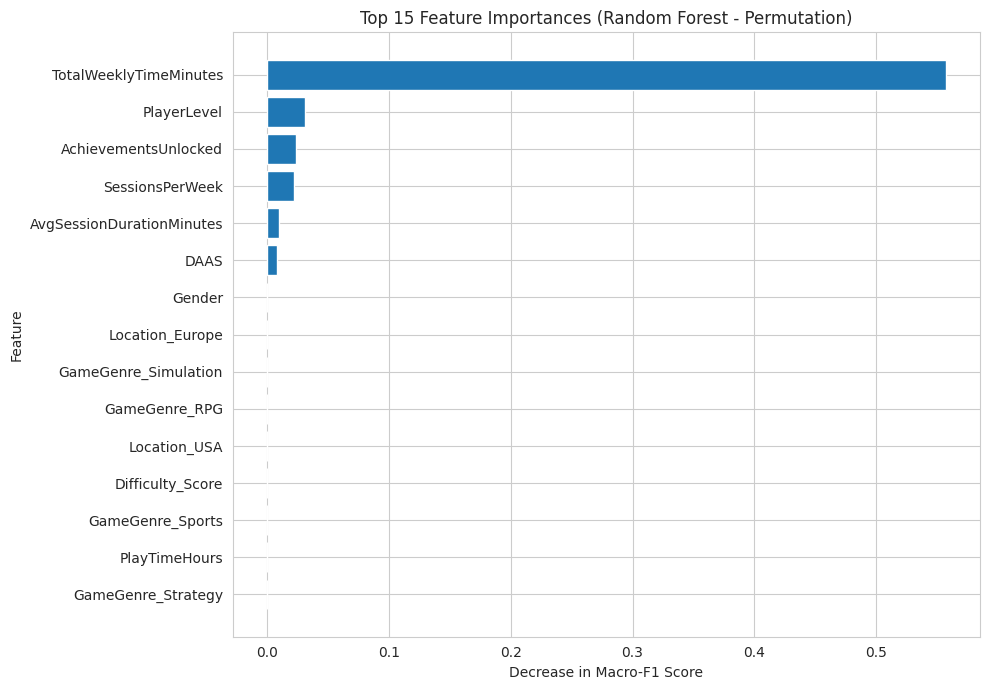

In [33]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

print("Permutation importance is being calculated (Random Forest)")

rf_used = best_rf if "best_rf" in globals() else rf_model

perm_rf = permutation_importance(
    rf_used,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"
)

rf_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_rf.importances_mean
}).sort_values("Importance", ascending=False)

# Tablo: Top 15
display(rf_importance_df.head(15))

# Görselleştirme
plt.figure(figsize=(10, 7))
plt.barh(
    rf_importance_df.head(15)["Feature"][::-1],
    rf_importance_df.head(15)["Importance"][::-1]
)
plt.title("Top 15 Feature Importances (Random Forest - Permutation)")
plt.xlabel("Decrease in Macro-F1 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



 Model 3: Support Vector Machines (SVM)


In [34]:
from sklearn.preprocessing import StandardScaler

X_train_svm = X_train.drop(columns=["PlayerID"]) if "PlayerID" in X_train.columns else X_train.copy()
X_test_svm = X_test.drop(columns=["PlayerID"]) if "PlayerID" in X_test.columns else X_test.copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_svm)
X_test_scaled = scaler.transform(X_test_svm)

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
import pandas as pd
import numpy as np

# Denenecek C değerleri
c_values = [0.1, 1, 10, 100]
tuning_results = []
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Hyperparameter Tuning: Testing C values")
for c in c_values:
    temp_svm = SVC(kernel="rbf", C=c, gamma="scale", random_state=42)
    # 3-Fold CV ile Macro-F1 hesaplıyoruz
    scores = cross_val_score(temp_svm, X_train_scaled, y_train, cv=cv3, scoring="f1_macro", n_jobs=-1)
    tuning_results.append({"C_Value": c, "Mean_Macro_F1": np.mean(scores)})
    print(f"C={c} Mean Macro-F1 for: {np.mean(scores):.4f}")


c_df = pd.DataFrame(tuning_results)
best_c = c_df.loc[c_df['Mean_Macro_F1'].idxmax(), 'C_Value']
display(c_df)
print(f"Optimal C: {best_c}")

Hyperparameter Tuning: Testing C values


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


C=0.1 Mean Macro-F1 for: 0.8749
C=1 Mean Macro-F1 for: 0.8887
C=10 Mean Macro-F1 for: 0.8767
C=100 Mean Macro-F1 for: 0.8294


,C_Value,Mean_Macro_F1
0,0.1,0.874911
1,1.0,0.888722
2,10.0,0.876693
3,100.0,0.829412


Optimal C: 1.0


Training Final SVM with C=1.0...
SVM Accuracy: 0.9025852379168228
SVM Macro-F1: 0.897919580881131


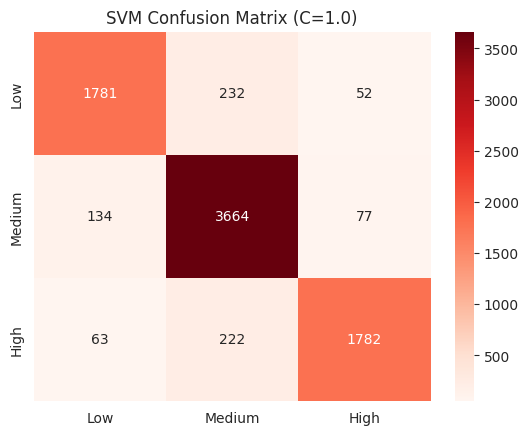

In [36]:
# Artık svm_model'i best_c ile tanımlıyoruz
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel="rbf", C=best_c, gamma="scale", random_state=42, probability= True)

print(f"Training Final SVM with C={best_c}...")
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("SVM Macro-F1:", f1_score(y_test, svm_pred, average="macro"))

# Confusion Matrix
cm = confusion_matrix(y_test, svm_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=["Low","Medium","High"], yticklabels=["Low","Medium","High"])
plt.title(f"SVM Confusion Matrix (C={best_c})")
plt.show()

SVM için K-Fold Cross Validation

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("SVM 3-Fold CV (within the training set) is starting")

# Macro-F1 (3-fold CV)
svm_cv_f1 = cross_val_score(
    svm_model,
    X_train_svm,
    y_train,
    cv=cv3,
    scoring="f1_macro",
    n_jobs=-1
)

# Accuracy (3-fold CV)
svm_cv_acc = cross_val_score(
    svm_model,
    X_train_svm,
    y_train,
    cv=cv3,
    scoring="accuracy",
    n_jobs=-1
)

print("Fold Macro-F1 scores:", svm_cv_f1)
print("Mean Macro-F1:", np.mean(svm_cv_f1))
print("Std Macro-F1:", np.std(svm_cv_f1))

print("Fold Accuracy scores:", svm_cv_acc)
print("Mean Accuracy:", np.mean(svm_cv_acc))
print("Std Accuracy:", np.std(svm_cv_acc))




SVM 3-Fold CV (within the training set) is starting
Fold Macro-F1 scores: [0.9041 0.9007 0.901 ]
Mean Macro-F1: 0.9019403923693865
Std Macro-F1: 0.0015360852621633496
Fold Accuracy scores: [0.9092 0.9053 0.9058]
Mean Accuracy: 0.9067661346672949
Std Accuracy: 0.0017562720258588542


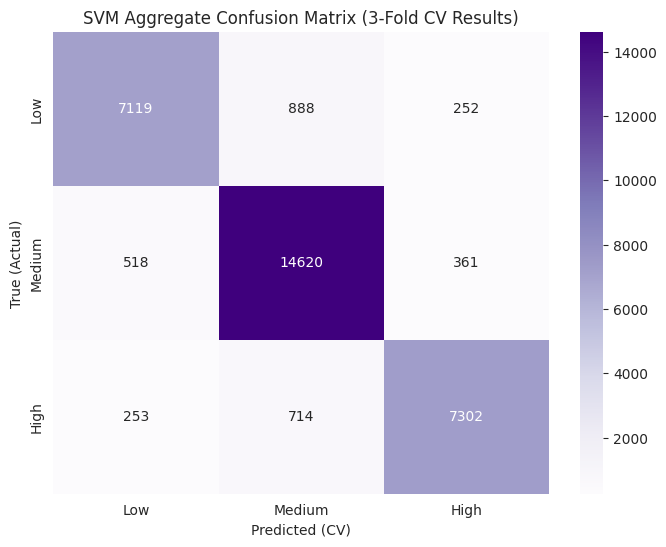

In [38]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_cv_pred = cross_val_predict(svm_model, X_train_svm, y_train, cv=cv3, n_jobs=-1)

# Karmaşıklık Matrisi
cm_cv = confusion_matrix(y_train, y_cv_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cv, annot=True, fmt='d', cmap='Purples',
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.xlabel('Predicted (CV)')
plt.ylabel('True (Actual)')
plt.title('SVM Aggregate Confusion Matrix (3-Fold CV Results)')
plt.show()

Permutation Importance

Permutation importance hesaplanıyor (Scaled veri kullanılarak).


,Feature,Importance
9,TotalWeeklyTimeMinutes,0.390711
5,SessionsPerWeek,0.191962
6,AvgSessionDurationMinutes,0.124924
7,PlayerLevel,0.026912
8,AchievementsUnlocked,0.023307
11,DAAS,0.004810
10,Difficulty_Score,0.003936
4,GameDifficulty,0.002978
2,PlayTimeHours,0.001239
12,Location_Europe,0.001185


/tmp/ipykernel_5290/948834742.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df.head(15), palette="viridis")


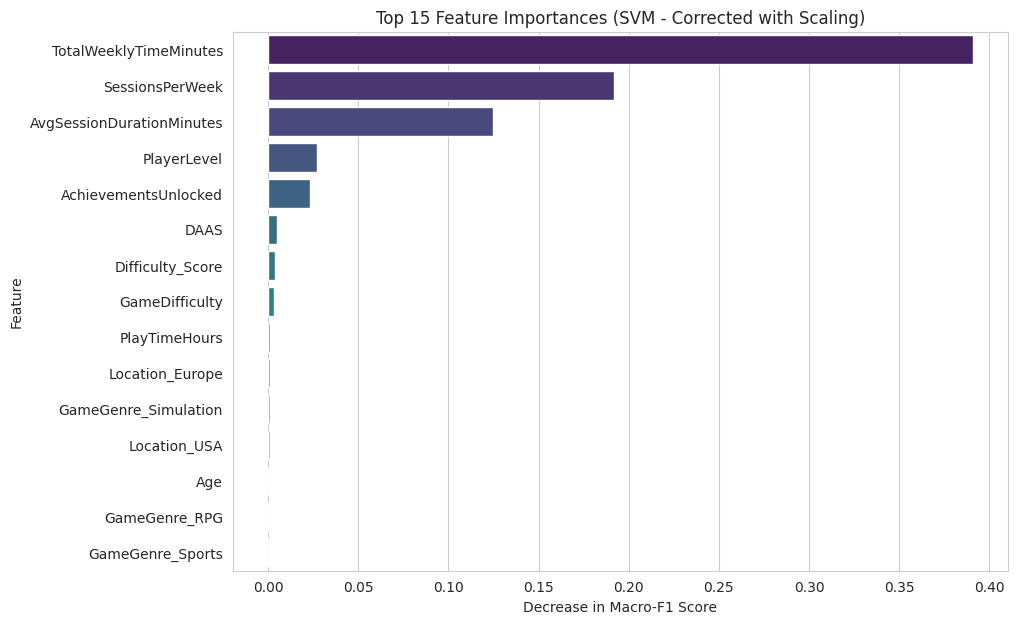

In [39]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Permutation importance hesaplanıyor (Scaled veri kullanılarak).")

perm = permutation_importance(
    svm_model,
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"
)


importance_df = pd.DataFrame({
    "Feature": X_test_svm.columns,
    "Importance": perm.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

# Görselleştirme
plt.figure(figsize=(10, 7))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(15), palette="viridis")
plt.title("Top 15 Feature Importances (SVM - Corrected with Scaling)")
plt.xlabel("Decrease in Macro-F1 Score")
plt.ylabel("Feature")
plt.show()

# XGBoost

## Import Libraries

In [40]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Overfitting Diagnosis Using Holdout Split

In [41]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Sadece teşhis için: training setin içinden küçük bir holdout çıkar
X_tr_diag, X_hold_diag, y_tr_diag, y_hold_diag = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

dtr_diag   = xgb.DMatrix(X_tr_diag,   label=y_tr_diag)
dhold_diag = xgb.DMatrix(X_hold_diag, label=y_hold_diag)

params_overfit = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "seed": 42,

    # Bilerek yüksek kapasite:
    "max_depth": 10,
    "eta": 0.2,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "lambda": 0.0,
    "alpha": 0.0,
    "gamma": 0.0,
}

evals_result_overfit = {}

xgb_overfit = xgb.train(
    params=params_overfit,
    dtrain=dtr_diag,
    num_boost_round=1500,
    evals=[(dtr_diag, "train"), (dhold_diag, "holdout")],
    evals_result=evals_result_overfit,
    verbose_eval=100
)

[0]	train-mlogloss:0.82521	holdout-mlogloss:0.83489
[100]	train-mlogloss:0.02007	holdout-mlogloss:0.38623
[200]	train-mlogloss:0.00609	holdout-mlogloss:0.45781
[300]	train-mlogloss:0.00345	holdout-mlogloss:0.49642
[400]	train-mlogloss:0.00238	holdout-mlogloss:0.52252
[500]	train-mlogloss:0.00186	holdout-mlogloss:0.54147
[600]	train-mlogloss:0.00151	holdout-mlogloss:0.55713
[700]	train-mlogloss:0.00126	holdout-mlogloss:0.57149
[800]	train-mlogloss:0.00110	holdout-mlogloss:0.58163
[900]	train-mlogloss:0.00098	holdout-mlogloss:0.59089
[1000]	train-mlogloss:0.00088	holdout-mlogloss:0.59922
[1100]	train-mlogloss:0.00080	holdout-mlogloss:0.60683
[1200]	train-mlogloss:0.00074	holdout-mlogloss:0.61360
[1300]	train-mlogloss:0.00069	holdout-mlogloss:0.61906
[1400]	train-mlogloss:0.00064	holdout-mlogloss:0.62440
[1499]	train-mlogloss:0.00061	holdout-mlogloss:0.62911


### Confusion Matrix (Pre-Regularization Model)

Holdout (Diagnostic) Accuracy: 0.9252263502965969
Holdout (Diagnostic) Macro-F1: 0.9205746453988191


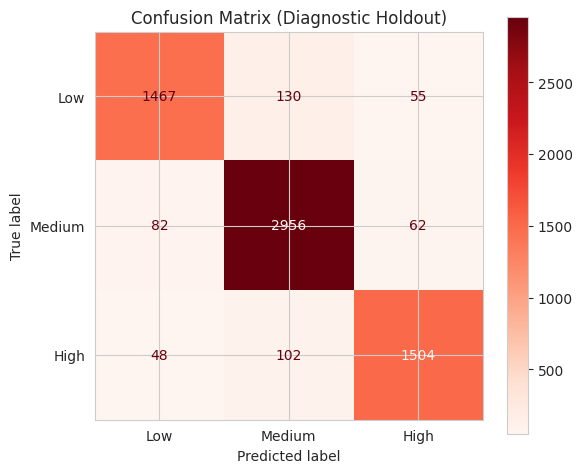

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_hold_overfit = np.argmax(xgb_overfit.predict(dhold_diag), axis=1)

# Metrics
print("Holdout (Diagnostic) Accuracy:", accuracy_score(y_hold_diag, y_pred_hold_overfit))
print("Holdout (Diagnostic) Macro-F1:", f1_score(y_hold_diag, y_pred_hold_overfit, average="macro"))

# Confusion Matrix
cm = confusion_matrix(y_hold_diag, y_pred_hold_overfit)

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(
    cmap="Reds",
    values_format="d",
    ax=ax,
    colorbar=True
)

ax.set_title("Confusion Matrix (Diagnostic Holdout)", fontsize=12)
plt.tight_layout()
plt.show()



### Learning Curve (Pre-Regularization Model)

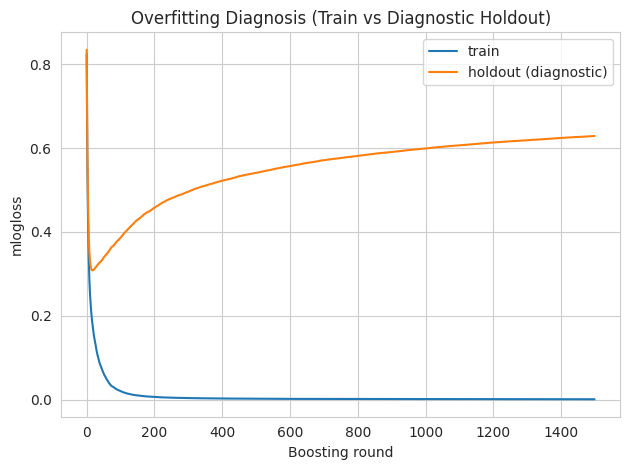

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(evals_result_overfit["train"]["mlogloss"], label="train")
plt.plot(evals_result_overfit["holdout"]["mlogloss"], label="holdout (diagnostic)")
plt.xlabel("Boosting round")
plt.ylabel("mlogloss")
plt.title("Overfitting Diagnosis (Train vs Diagnostic Holdout)")
plt.legend()
plt.tight_layout()
plt.show()

## Overfitting Mitigation via Regularization

In [44]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split


X_tr_diag, X_hold_diag, y_tr_diag, y_hold_diag = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

dtr_diag   = xgb.DMatrix(X_tr_diag, label=y_tr_diag)
dhold_diag = xgb.DMatrix(X_hold_diag, label=y_hold_diag)

params_fixed = {
    "objective": "multi:softprob",
    "num_class": 3,
    "max_depth": 5,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "gamma": 0.5,
    "lambda": 2.0,
    "alpha": 0.2,
    "eval_metric": "mlogloss",
    "seed": 42
}

evals_result_fixed = {}

xgb_fixed = xgb.train(
    params=params_fixed,
    dtrain=dtr_diag,
    num_boost_round=4000,
    evals=[(dtr_diag, "train"), (dhold_diag, "holdout")],
    early_stopping_rounds=50,
    evals_result=evals_result_fixed,
    verbose_eval=100
)

print("Best iteration:", xgb_fixed.best_iteration)
print("Best holdout score:", xgb_fixed.best_score)


[0]	train-mlogloss:0.99668	holdout-mlogloss:0.99694
[100]	train-mlogloss:0.29243	holdout-mlogloss:0.30977
[191]	train-mlogloss:0.27047	holdout-mlogloss:0.30959
Best iteration: 141
Best holdout score: 0.30908132949567774


### Learning Curve After Regularization

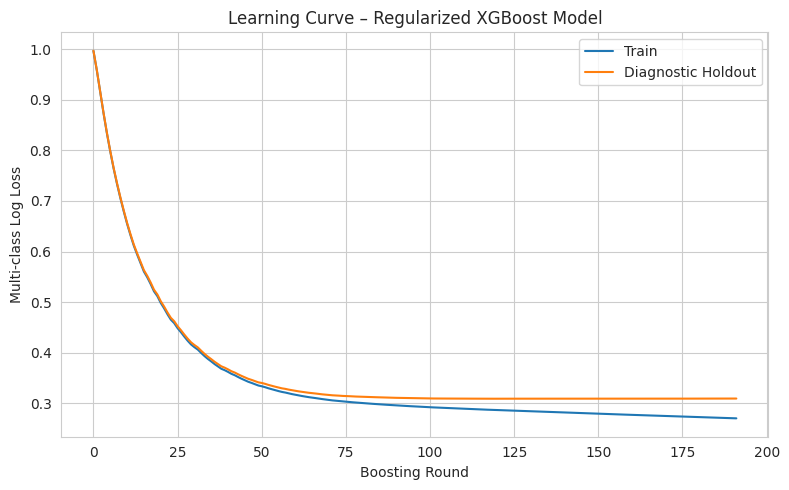

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    evals_result_fixed["train"]["mlogloss"],
    label="Train"
)

plt.plot(
    evals_result_fixed["holdout"]["mlogloss"],
    label="Diagnostic Holdout"
)

plt.xlabel("Boosting Round")
plt.ylabel("Multi-class Log Loss")
plt.title("Learning Curve – Regularized XGBoost Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Post-Regularization Model Evaluation (Holdout)

In [46]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Train ve Test DMatrix
dtrain_full = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

best_rounds = xgb_fixed.best_iteration + 1

xgb_final = xgb.train(
    params=params_fixed,
    dtrain=dtrain_full,
    num_boost_round=best_rounds,
    verbose_eval=False
)

y_pred_test = np.argmax(xgb_final.predict(dtest), axis=1)

print("FINAL Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("FINAL Test Macro-F1:", f1_score(y_test, y_pred_test, average="macro"))

print("\nFINAL Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test))

print("\nFINAL Classification Report:")
print(classification_report(y_test, y_pred_test))


FINAL Test Accuracy: 0.9274384913200949
FINAL Test Macro-F1: 0.9232933599494798

FINAL Confusion Matrix:
[[1868  145   52]
 [ 103 3703   69]
 [  63  149 1855]]

FINAL Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2065
           1       0.93      0.96      0.94      3875
           2       0.94      0.90      0.92      2067

    accuracy                           0.93      8007
   macro avg       0.93      0.92      0.92      8007
weighted avg       0.93      0.93      0.93      8007



# Hyperparameter Selection Using K-Fold Cross-Validation

## Hyperparameter Search Space

In [47]:


import xgboost as xgb
from sklearn.model_selection import ParameterGrid
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

base_params = {
    "objective": "multi:softprob",
    "num_class": 3,
    "eval_metric": "mlogloss",
    "seed": 42
}

param_grid = {
    "max_depth": [4, 5],
    "eta": [0.03, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "gamma": [0.0, 0.5],
    "lambda": [1.0, 2.0],
    "alpha": [0.0, 0.2],
}

best_score = float("inf")
best_params = None
best_rounds = None

cv_log = []

for params in ParameterGrid(param_grid):
    cv_params = {**base_params, **params}

    cv_results = xgb.cv(
        params=cv_params,
        dtrain=dtrain,
        nfold=3,
        num_boost_round=1500,
        early_stopping_rounds=30,
        stratified=True,
        verbose_eval=False,
        seed=42
    )

    score = cv_results["test-mlogloss-mean"].iloc[-1]
    rounds = len(cv_results)

    cv_log.append({
        **params,
        "test_mlogloss_mean": float(score),
        "best_rounds": int(rounds)
    })

    if score < best_score:
        best_score = score
        best_params = cv_params
        best_rounds = rounds


## Final Model Training Using Best CV Parameters

In [48]:
"""## Final Model"""

dtrain_full = xgb.DMatrix(X_train, label=y_train)
dtest       = xgb.DMatrix(X_test,  label=y_test)

xgb_final = xgb.train(
    params=best_params,
    dtrain=dtrain_full,
    num_boost_round=best_rounds,
    verbose_eval=False
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import numpy as np

y_pred_test = np.argmax(xgb_final.predict(dtest), axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("Test Macro-F1:", f1_score(y_test, y_pred_test, average="macro"))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))


Test Accuracy: 0.9270638191582365
Test Macro-F1: 0.9229045674624311

Confusion Matrix:
 [[1866  146   53]
 [ 102 3703   70]
 [  62  151 1854]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      2065
           1       0.93      0.96      0.94      3875
           2       0.94      0.90      0.92      2067

    accuracy                           0.93      8007
   macro avg       0.93      0.92      0.92      8007
weighted avg       0.93      0.93      0.93      8007



## Final Model Confusion Matrix (Test Set)

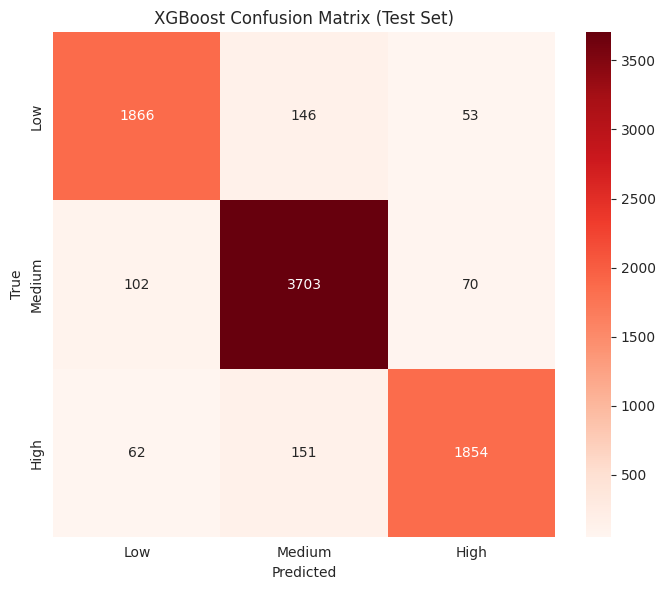

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ["Low", "Medium", "High"]

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Confusion Matrix (Test Set)")
plt.tight_layout()


plt.savefig("xgboost_confusion_matrix.png", dpi=300)
plt.show()

## Cross-Validation Results Summary

In [50]:
"""## Deneme Tablosu"""

import pandas as pd

cv_df = pd.DataFrame(cv_log).sort_values("test_mlogloss_mean").reset_index(drop=True)
cv_df.head(10)


,alpha,colsample_bytree,eta,gamma,lambda,max_depth,subsample,test_mlogloss_mean,best_rounds
0,0.0,0.8,0.05,0.5,1.0,5,0.8,0.311359,141
1,0.2,0.8,0.05,0.0,1.0,5,0.8,0.311403,141
2,0.0,0.8,0.03,0.5,1.0,5,0.8,0.311417,212
3,0.0,0.8,0.03,0.0,2.0,5,0.8,0.311454,222
4,0.2,0.8,0.05,0.5,1.0,5,0.8,0.311464,141
5,0.0,0.8,0.03,0.5,2.0,5,0.8,0.311478,222
6,0.2,0.8,0.03,0.5,1.0,5,0.8,0.311487,212
7,0.2,0.8,0.05,0.5,2.0,5,0.8,0.311487,141
8,0.0,0.8,0.03,0.0,1.0,5,0.8,0.311487,202
9,0.2,0.8,0.03,0.0,1.0,5,0.8,0.311491,212


## Feature Importance

,Feature,Importance
9,TotalWeeklyTimeMinutes,5.848337e-01
7,PlayerLevel,3.679944e-02
8,AchievementsUnlocked,3.517154e-02
11,DAAS,1.532710e-03
5,SessionsPerWeek,7.958701e-04
13,Location_Other,1.032795e-04
2,PlayTimeHours,1.000586e-04
15,GameGenre_RPG,5.107182e-05
18,GameGenre_Strategy,2.581987e-05
14,Location_USA,-5.197543e-09


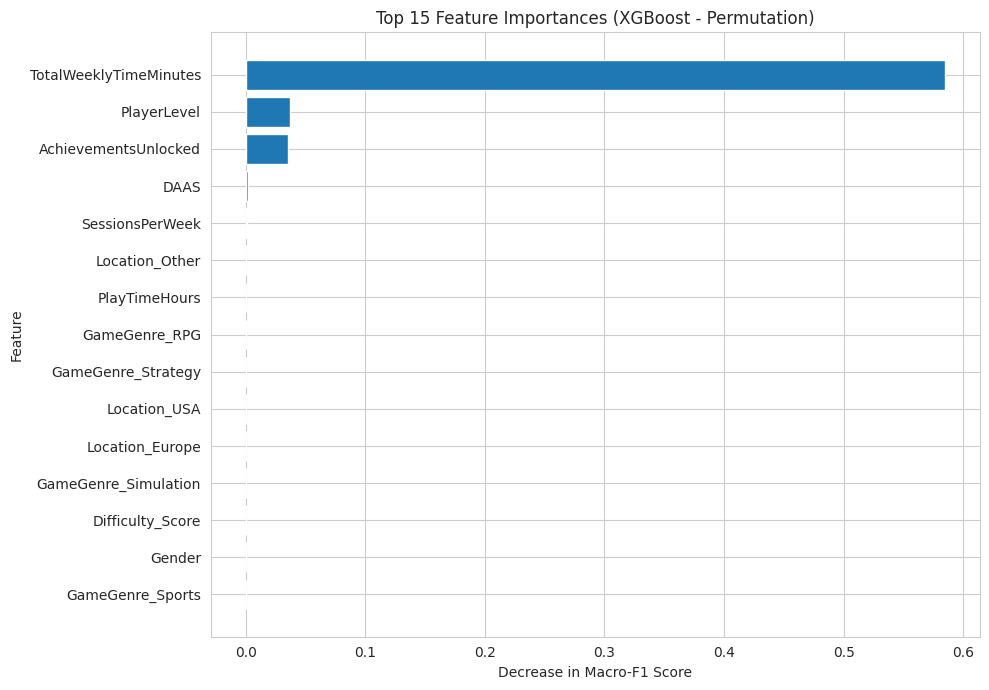

In [51]:
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt


xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=best_rounds,
    max_depth=best_params["max_depth"],
    learning_rate=best_params["eta"],
    subsample=best_params["subsample"],
    colsample_bytree=best_params["colsample_bytree"],
    gamma=best_params["gamma"],
    reg_alpha=best_params["alpha"],
    reg_lambda=best_params["lambda"],
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

perm_xgb = permutation_importance(
    xgb_clf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"
)

importance_xgb_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_xgb.importances_mean
}).sort_values("Importance", ascending=False)

display(importance_xgb_df.head(15))

plt.figure(figsize=(10, 7))
plt.barh(
    importance_xgb_df.head(15)["Feature"][::-1],
    importance_xgb_df.head(15)["Importance"][::-1]
)
plt.title("Top 15 Feature Importances (XGBoost - Permutation)")
plt.xlabel("Decrease in Macro-F1 Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


ROC CURVE

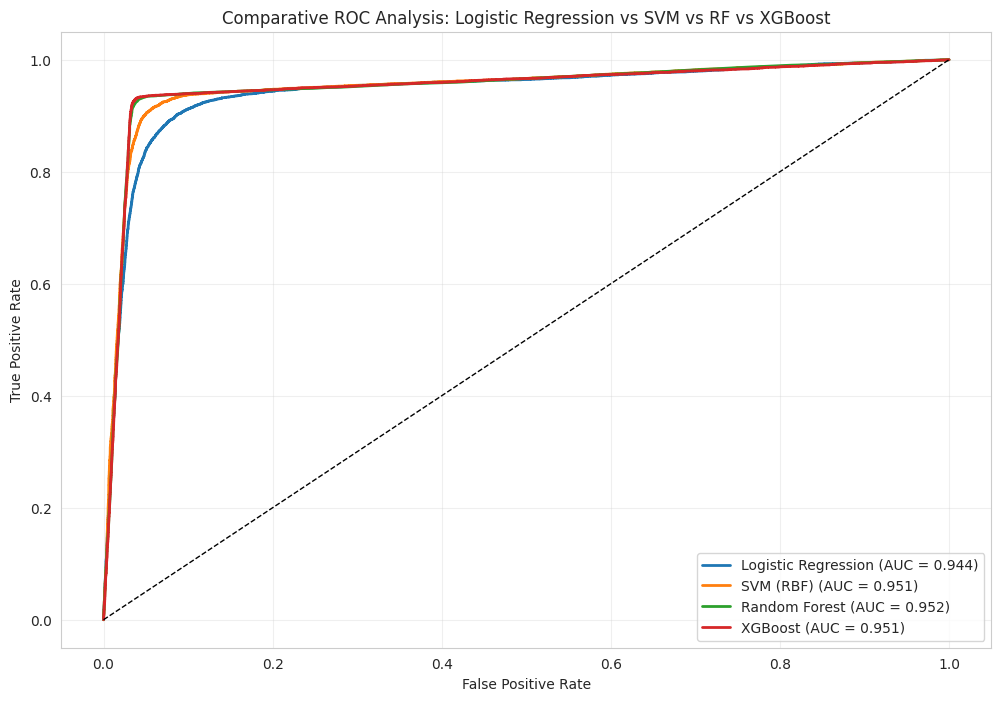

In [52]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import xgboost as xgb

models = {
    "Logistic Regression": log_model,
    "SVM (RBF)": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_final
}

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
plt.figure(figsize=(12, 8))

for model_name, model in models.items():

    if model_name == "SVM (RBF)":
        y_score = model.predict_proba(X_test_scaled)
    elif "Booster" in str(type(model)):
        dtest = xgb.DMatrix(X_test)
        y_score = model.predict(dtest)
    else:
        y_score = model.predict_proba(X_test)

    # 2. Macro-average ROC hesaplama (tüm sınıflar için genel performans)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Analysis: Logistic Regression vs SVM vs RF vs XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()